### Example of coalition in the Bankruptcy game

In [2]:
import os
import sys
import math
import pandas as pd
import shap


sys.path.append(os.path.join("..", "..", "."))

file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_value_of_bankruptcy.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_bankruptcy.csv"
)
original = pd.read_csv(os.path.join(
    "..", "..", "data", "input", "bankruptcy.csv"
), sep=";").set_index(
    "label",
    verify_integrity=True
)

shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only = shapley_only.set_index(
    original.index.values,
    verify_integrity=True
)

psi_1 = original.join(shapley_only)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
).set_index(
    original.index.values,
    verify_integrity=True
)
r_1.columns = original.index.values

### Truncated characteristic values

In [3]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


#### Benefit Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_value_of_bankruptcy.csv. In the table below we represent these values:

In [4]:
psi_1_truncated

,lender,debt,value
label,,,
SL1,Small Lender 1,50,29.9404
SL2,Small Lender 2,50,29.9404
SL3,Small Lender 3,50,29.9404
SL4,Small Lender 4,50,29.9404
SL5,Small Lender 5,50,29.9404
ML1,Medium Lender 1,200,119.8611
ML2,Medium Lender 2,200,119.8611
ML3,Medium Lender 3,200,119.8611
LL1,Large Lender 1,400,245.3571


In [5]:
psi_2_truncated

,lender,debt,value
label,,,
SL1,Small Lender 1,50,0.1220
SL2,Small Lender 2,50,0.1220
SL3,Small Lender 3,50,0.1220
SL4,Small Lender 4,50,0.1220
SL5,Small Lender 5,50,0.1220
ML1,Medium Lender 1,200,0.4885
ML2,Medium Lender 2,200,0.4885
ML3,Medium Lender 3,200,0.4885
LL1,Large Lender 1,400,1.0000


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_bankruptcy.csv. In the following table, we represent these values.

In [6]:
r_1_truncated

,SL1,SL2,SL3,SL4,SL5,ML1,ML2,ML3,LL1,LL2
SL1,0.0000,1.2896,1.2896,1.2896,1.2896,5.8730,5.8730,5.8730,13.6111,13.6111
SL2,1.2896,0.0000,1.2896,1.2896,1.2896,5.8730,5.8730,5.8730,13.6111,13.6111
SL3,1.2896,1.2896,0.0000,1.2896,1.2896,5.8730,5.8730,5.8730,13.6111,13.6111
SL4,1.2896,1.2896,1.2896,0.0000,1.2896,5.8730,5.8730,5.8730,13.6111,13.6111
SL5,1.2896,1.2896,1.2896,1.2896,0.0000,5.8730,5.8730,5.8730,13.6111,13.6111
ML1,5.8730,5.8730,5.8730,5.8730,5.8730,0.0000,27.4801,27.4801,57.8373,57.8373
ML2,5.8730,5.8730,5.8730,5.8730,5.8730,27.4801,0.0000,27.4801,57.8373,57.8373
ML3,5.8730,5.8730,5.8730,5.8730,5.8730,27.4801,27.4801,0.0000,57.8373,57.8373
LL1,13.6111,13.6111,13.6111,13.6111,13.6111,57.8373,57.8373,57.8373,0.0000,158.4325
LL2,13.6111,13.6111,13.6111,13.6111,13.6111,57.8373,57.8373,57.8373,158.4325,0.0000


In [7]:
r_2_truncated

,SL1,SL2,SL3,SL4,SL5,ML1,ML2,ML3,LL1,LL2
SL1,0.0000,0.0081,0.0081,0.0081,0.0081,0.0370,0.0370,0.0370,0.0859,0.0859
SL2,0.0081,0.0000,0.0081,0.0081,0.0081,0.0370,0.0370,0.0370,0.0859,0.0859
SL3,0.0081,0.0081,0.0000,0.0081,0.0081,0.0370,0.0370,0.0370,0.0859,0.0859
SL4,0.0081,0.0081,0.0081,0.0000,0.0081,0.0370,0.0370,0.0370,0.0859,0.0859
SL5,0.0081,0.0081,0.0081,0.0081,0.0000,0.0370,0.0370,0.0370,0.0859,0.0859
ML1,0.0370,0.0370,0.0370,0.0370,0.0370,0.0000,0.1734,0.1734,0.3650,0.3650
ML2,0.0370,0.0370,0.0370,0.0370,0.0370,0.1734,0.0000,0.1734,0.3650,0.3650
ML3,0.0370,0.0370,0.0370,0.0370,0.0370,0.1734,0.1734,0.0000,0.3650,0.3650
LL1,0.0859,0.0859,0.0859,0.0859,0.0859,0.3650,0.3650,0.3650,0.0000,1.0000
LL2,0.0859,0.0859,0.0859,0.0859,0.0859,0.3650,0.3650,0.3650,1.0000,0.0000


In [8]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0; \beta^{-} = 0}^{2}$

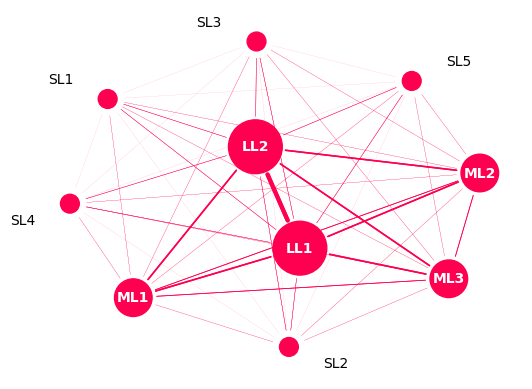

In [13]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    layout="spring",
    label_margin=0.10,
    positive_color=positive_color,
    negative_color=negative_color,
    # output_path=os.path.join("..", "..", "results", "bankruptcy-0-0-0-0.jpg")
)

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0.25; \beta^{-} = 0}^{2}$

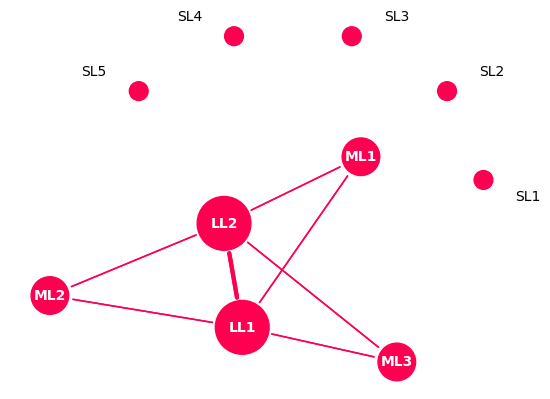

In [10]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0.25,
    negative_beta=0,
    symmetric=True,
    layout="kamada_kawai",
    label_margin=0.08,
    positive_color=positive_color,
    negative_color=negative_color,
    # output_path=os.path.join("..", "..", "results", "bankruptcy-0-0-025-0.jpg")
)